
# Assignment 1: Exploring Word Embeddings
**Course Name:** Natural Language Processing (CSC6052/5051//MDS5110)





*Please enter your personal information (make sure you have copied this colab)*

**Name:**

**Student ID:**






In [1]:
# Local execution: choose the conda NLP kernel in VS Code.
# If dependencies are missing, run the following with this kernel, then restart it:
# %pip install torch matplotlib scikit-learn nltk gensim "bokeh>=3.6,<4" pandas tqdm gdown

## Assignment Requirements

This Colab file includes all contents for Assignment 1.

#### You are required to:

1. **Make a copy of the provided Google Colab file.**  
   First, you need to make a copy of the provided file into your own Google Drive. To accomplish this, open the Colab file link, navigate to `File` → `Save a copy in Drive`.

2. **Execute the notebook to generate results.**  
   You can click on "Connect to GPU" to apply for a free T4 GPU. Then, you can press the large play button to run a code cell.

3. **Complete the Necessary Parts.**  
   Some sections of the code are incomplete and require your input, especially pay attention to the parts marked with **<font color="red">[Task]</font>**. These sections are critical for scoring the assignment.

For more detailed instructions, refer to [Working with Google Colab](https://docs.google.com/document/d/1vMe8kC-oSyP3w7rIurDbG3NqfyQw7sZJ2C_S2ngtQnk/edit?usp=sharing).

## Submission Guidelines

Follow these steps to submit your assignment:

1. **Export the Notebook:** Navigate to `File` → `Download .ipynb` to download your notebook.

2. **Upload Your File:** Access the [Blackboard system](https://bb.cuhk.edu.cn/) and upload your `.ipynb` file.


## Overview

*Assignment 1* consists of two tasks:
- Task 1: Train Word Embeddings with Word2Vec (5 points)
- Task 2: Explore word embeddings (3 ponits)
- Task 3: Utilize word embeddings (2 points)

Your task is to **run all the code in this script** and complete the parts marked with <font color="red">[task]</font>.

## Prerequisite
If you're new to Python, Numpy, or PyTorch, consider these tutorials for a quick start:
- [Python-Numpy-Tutorial](https://cs231n.github.io/python-numpy-tutorial/)
- [Introduction to PyTorch](https://colab.research.google.com/drive/1obAmmGHsMizB38aiZJ_-L1bVMT5KOLMd?usp=sharing)

## Task 1: Train Word Embeddings with Word2Vec

**In this task, you will implement and train your own Word2Vec model.**

Before diving in, let's clarify what Word2Vec is.

Its core concept is straightforward: you can infer the meaning of a word from its neighbors - the words that frequently appear in the same context. Consider this illustration:
![Contexts](https://image.ibb.co/mnQ2uz/2018_09_17_21_07_08.png)

A basic approach is to use the context word counts as meaningful word vectors. Take this simple corpus for example:

```
The red fox jumped
The brown fox jumped
```

The count vectors would look like this:
```
        the fox jumped red brown
red   = (1   1    1     0    0)
brown = (1   1    1     0    0)
```

Notice how `red` and `brown` have similar vectors! We're close to solving the problem, but the goal is to obtain more compact embedding vectors.

This is where Word2Vec algorithms come into play. They construct embedding vectors based on the word's neighbors in the corpus.

For a more detailed introduction, check out this post: [king - man + woman = queen; but why?](http://p.migdal.pl/2017/01/06/king-man-woman-queen-why.html).

Let's do some preparation work before moving to the interesting stuff.



### **1.1 Preparation**

Environment installation and data download

In [2]:
import os
import sys
import random
import time
import math
import hashlib
from pathlib import Path
from datetime import datetime, timezone

# Locate the assignment from either its root or the report directory.
TASK_DIR = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'requirements' / 'Assignment_1.pdf').is_file()), Path.cwd())
CACHE_DIR = TASK_DIR / 'data' / 'downloads'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('GENSIM_DATA_DIR', str(CACHE_DIR / 'gensim'))
os.environ.setdefault('MPLCONFIGDIR', str(TASK_DIR / '.cache' / 'matplotlib'))

import nltk
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
from nltk.tokenize import word_tokenize
from tqdm import tqdm
from IPython.display import clear_output
%matplotlib inline

nltk_dir = CACHE_DIR / 'nltk_data'
nltk.data.path.insert(0, str(nltk_dir))
# NLTK 3.8 uses punkt; 3.9+ uses punkt_tab. Checking punkt_tab with
# NLTK 3.8 triggers its legacy PY3 path rewriting, so select by version.
nltk_version = tuple(int(part) for part in nltk.__version__.split('.')[:2])
resources = [('punkt_tab', 'tokenizers/punkt_tab/english/')] if nltk_version >= (3, 9) else [('punkt', 'tokenizers/punkt')]
for resource, locator in resources:
    try:
        nltk.data.find(locator)
    except LookupError:
        if not nltk.download(resource, download_dir=str(nltk_dir), quiet=True):
            raise RuntimeError(f'Unable to download NLTK resource: {resource}')

# Reuse the supplied Quora data; only download if no local copy exists.
DATA_PATH = next((p for p in [Path.cwd() / 'train.csv', TASK_DIR / 'report' / 'train.csv',
                             CACHE_DIR / 'quora' / 'train.csv'] if p.is_file()), None)
if DATA_PATH is None:
    import gdown
    import zipfile
    archive = CACHE_DIR / 'quora.zip'
    gdown.download(id='1ERtxpdWOgGQ3HOigqAMHTJjmOE_tWvoF', output=str(archive), quiet=False)
    with zipfile.ZipFile(archive) as z:
        member = next(name for name in z.namelist() if Path(name).name == 'train.csv')
        destination = CACHE_DIR / 'quora'
        destination.mkdir(exist_ok=True)
        DATA_PATH = destination / 'train.csv'
        with z.open(member) as src, DATA_PATH.open('wb') as dst:
            import shutil
            shutil.copyfileobj(src, dst)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
torch.set_num_threads(min(8, os.cpu_count() or 1))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
RUN_DIR = TASK_DIR / 'results' / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)
print('Python:', sys.version.split()[0], '| PyTorch:', torch.__version__)
print('Device:', device, torch.cuda.get_device_name(0) if device.type == 'cuda' else '')
print('Seed:', SEED, '| Quora SHA256:', hashlib.sha256(DATA_PATH.read_bytes()).hexdigest())
print('Run ID:', RUN_ID)

OSError: No such file or directory: '/home/scarramcci/Project/MCS_CUHK-SZ/CSC5051_Natural_Language_Processing/assignments/hw01/data/downloads/nltk_data/tokenizers/punkt/PY3_tab/english'

1. Tokenize and lower-case texts.

In [3]:
quora_data = pd.read_csv(DATA_PATH)
quora_data.question1 = quora_data.question1.fillna('')
quora_data.question2 = quora_data.question2.fillna('')
texts = list(pd.concat([quora_data.question1, quora_data.question2]).unique())
texts = texts[:50000]  # Keep the assignment's accelerated corpus size.
print(len(texts))
tokenized_texts = [word_tokenize(text.lower()) for text in tqdm(texts)]
assert len(tokenized_texts) == len(texts)
assert isinstance(tokenized_texts[0], list)
assert isinstance(tokenized_texts[0][0], str)

50000


  0%|          | 0/50000 [00:00<?, ?it/s]

  5%|▍         | 2324/50000 [00:00<00:02, 23234.09it/s]

 10%|▉         | 4752/50000 [00:00<00:01, 23847.48it/s]

 14%|█▍        | 7225/50000 [00:00<00:01, 24246.60it/s]

 19%|█▉        | 9665/50000 [00:00<00:01, 24305.12it/s]

 24%|██▍       | 12097/50000 [00:00<00:01, 24308.76it/s]

 29%|██▉       | 14528/50000 [00:00<00:01, 18117.96it/s]

 34%|███▍      | 16992/50000 [00:00<00:01, 19850.26it/s]

 39%|███▉      | 19451/50000 [00:00<00:01, 21152.70it/s]

 44%|████▎     | 21834/50000 [00:01<00:01, 21907.87it/s]

 48%|████▊     | 24225/50000 [00:01<00:01, 22482.35it/s]

 53%|█████▎    | 26662/50000 [00:01<00:01, 23029.49it/s]

 58%|█████▊    | 29081/50000 [00:01<00:00, 23368.81it/s]

 63%|██████▎   | 31530/50000 [00:01<00:00, 23698.68it/s]

 68%|██████▊   | 33937/50000 [00:01<00:00, 23803.99it/s]

 73%|███████▎  | 36384/50000 [00:01<00:00, 24001.87it/s]

 78%|███████▊  | 38815/50000 [00:01<00:00, 24092.28it/s]

 82%|████████▏ | 41236/50000 [00:01<00:00, 24126.20it/s]

 87%|████████▋ | 43656/50000 [00:01<00:00, 23851.28it/s]

 92%|█████████▏| 46047/50000 [00:02<00:00, 23799.42it/s]

 97%|█████████▋| 48462/50000 [00:02<00:00, 23899.65it/s]

100%|██████████| 50000/50000 [00:02<00:00, 23055.59it/s]

In [4]:
print(tokenized_texts[0])

['what', 'is', 'the', 'step', 'by', 'step', 'guide', 'to', 'invest', 'in', 'share', 'market', 'in', 'india', '?']


2. Collect the indices of the words:

In [5]:
from collections import Counter

MIN_COUNT = 5

words_counter = Counter(token for tokens in tokenized_texts for token in tokens)
word2index = {
    '<unk>': 0
}

for word, count in words_counter.most_common():
    if count < MIN_COUNT:
        break

    word2index[word] = len(word2index)

index2word = [word for word, _ in sorted(word2index.items(), key=lambda x: x[1])]

print('Vocabulary size:', len(word2index))
print('Tokens count:', sum(len(tokens) for tokens in tokenized_texts))
print('Unknown tokens appeared:', sum(1 for tokens in tokenized_texts for token in tokens if token not in word2index))
print('Most freq words:', index2word[1:21])

Vocabulary size: 7226
Tokens count: 623563
Unknown tokens appeared: 35607
Most freq words: ['?', 'the', 'what', 'is', 'how', 'i', 'a', 'to', 'in', 'do', 'of', 'are', 'and', 'can', 'for', ',', 'you', 'why', 'it', 'best']


3. collect the context words

First of all, we need to collect all the contexts from our corpus.

In [6]:
def build_contexts(tokenized_texts, window_size):
    contexts = []
    for tokens in tokenized_texts:
        for i in range(len(tokens)):
            central_word = tokens[i]
            context = [tokens[i + delta] for delta in range(-window_size, window_size + 1)
                       if delta != 0 and i + delta >= 0 and i + delta < len(tokens)]

            contexts.append((central_word, context))

    return contexts

contexts = build_contexts(tokenized_texts, window_size=2)

Check, what you got:

In [7]:
contexts[:5]

[('what', ['is', 'the']),
 ('is', ['what', 'the', 'step']),
 ('the', ['what', 'is', 'step', 'by']),
 ('step', ['is', 'the', 'by', 'step']),
 ('by', ['the', 'step', 'step', 'guide'])]

4. Convert to indices

Let's convert words to indices:

In [8]:
contexts = [(word2index.get(central_word, 0), [word2index.get(word, 0) for word in context])
            for central_word, context in contexts]

### **1.2 Continuous Bag of Words (CBoW) Word2vec**

We have learn skip-gram model in tutorial. Now, we will explore another popular Word2Vec paradigm called Continuous Bag of Words (CBoW). *CBoW* offers faster processing and slightly better accuracy for common words compared to the *Skip-Gram*, which is more effective with rare words.

**CBoW Structure**

Below is the CBoW model architecture:

![](https://i.ibb.co/StXTMFH/CBOW.png)

In CBoW, the goal is to predict a target word from its surrounding context, represented by the sum of context vectors.

We will leverage our understanding from the *Skip-Gram* model to implement *CBoW*.

1. **Batches Generations**
**<font color="red">[Task]</font>** : Implement the batch generator.

**Hint**: The generator should produce a input matrix `(batch_size, 2 * window_size)` containing context word indices and a target matrix `(batch_size)` with central word indices.

In [9]:
def make_cbow_batches_iter(contexts, window_size, batch_size):
    if window_size <= 0 or batch_size <= 0:
        raise ValueError('window_size and batch_size must be positive')
    valid = [(word, context) for word, context in contexts
             if len(context) == 2 * window_size and word != 0]
    central_words = np.array([word for word, _ in valid], dtype=np.int64)
    context_tokens = np.array([context for _, context in valid], dtype=np.int64)
    batches_count = math.ceil(len(valid) / batch_size)
    print(f'Initializing batches generator with {batches_count} batches per epoch')
    indices = np.random.permutation(len(valid))
    for i in range(batches_count):
        batch_indices = indices[i * batch_size:(i + 1) * batch_size]
        yield {'tokens': torch.from_numpy(context_tokens[batch_indices]),
               'labels': torch.from_numpy(central_words[batch_indices])}

Check it:

In [10]:
window_size = 2
batch_size = 32

batch = next(make_cbow_batches_iter(contexts, window_size=window_size, batch_size=batch_size))

assert isinstance(batch, dict)
assert 'labels' in batch and 'tokens' in batch

assert isinstance(batch['tokens'], torch.LongTensor)
assert isinstance(batch['labels'], torch.LongTensor)

assert batch['tokens'].shape == (batch_size, 2 * window_size)
assert batch['labels'].shape == (batch_size,)

Initializing batches generator with 12380 batches per epoch


2. **Model**
**<font color="red">[Task]</font>**: Build the `CBoWModel`.

**Hint**: You need to implement the `forward` method based on the CBoW architecture. The context embedding is represented as the average of their context embeddings.

In [11]:
class CBoWModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.out_layer = nn.Linear(embedding_dim, vocab_size)

    def forward(self, inputs):
        # Average across context positions, preserving the batch dimension.
        context_embedding = self.embeddings(inputs).mean(dim=1)
        # CrossEntropyLoss takes raw logits, so no softmax is applied here.
        return self.out_layer(context_embedding)

Check it:

In [12]:
model = CBoWModel(vocab_size=len(word2index), embedding_dim=32).to(device)
outputs = model(batch['tokens'].to(device))
assert outputs.dtype == torch.float32
assert outputs.device.type == device.type
assert outputs.shape == (batch_size, len(word2index))
print('Model check passed:', tuple(outputs.shape), outputs.device)

Model check passed: (32, 7226) cuda:0


3. **Training**
**<font color="red">[Task]</font>** : Train the CBoW.

**Hint**: Consider referring to the training code of the previously mentioned *Skip-gram* model.

Initializing batches generator with 3095 batches per epoch


Epoch 1, step 3000, average loss 6.4760


Epoch 1/4: mean loss = 6.4539


Initializing batches generator with 3095 batches per epoch


Epoch 2, step 2905, average loss 5.5352


Epoch 2/4: mean loss = 5.5262


Initializing batches generator with 3095 batches per epoch


Epoch 3, step 2810, average loss 5.2241


Epoch 3/4: mean loss = 5.2168


Initializing batches generator with 3095 batches per epoch


Epoch 4, step 2715, average loss 5.0303


Epoch 4/4: mean loss = 5.0247


Training time: 7.71 seconds


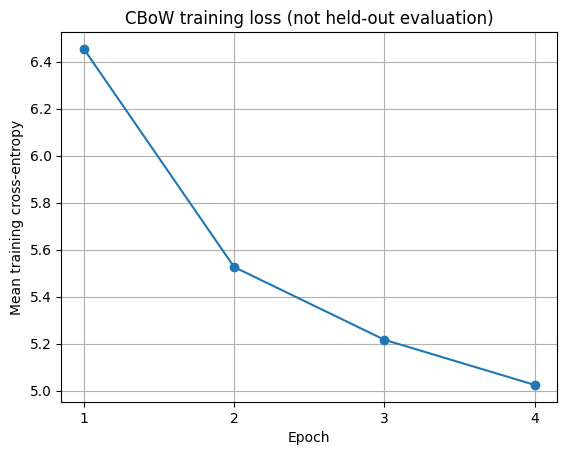

In [13]:
embedding_dim = 32
learning_rate = 0.001
epoch_num = 4
batch_size = 128

torch.manual_seed(SEED)
model = CBoWModel(len(word2index), embedding_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_every_nsteps = 3000
global_step = 0
training_history = []
training_start = time.perf_counter()

for ep in range(epoch_num):
    model.train()
    epoch_loss, epoch_examples = 0.0, 0
    interval_loss, interval_examples = 0.0, 0
    for step, batch in enumerate(make_cbow_batches_iter(contexts, window_size=2, batch_size=batch_size)):
        tokens = batch['tokens'].to(device)
        labels = batch['labels'].to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(tokens)
        loss = criterion(logits, labels)
        if not torch.isfinite(loss):
            raise RuntimeError('Non-finite training loss')
        loss.backward()
        optimizer.step()
        global_step += 1
        count = labels.size(0)
        epoch_loss += loss.item() * count
        epoch_examples += count
        interval_loss += loss.item() * count
        interval_examples += count
        if global_step % loss_every_nsteps == 0:
            print(f'Epoch {ep + 1}, step {step + 1}, average loss {interval_loss / interval_examples:.4f}', flush=True)
            interval_loss, interval_examples = 0.0, 0
    if epoch_examples == 0:
        raise RuntimeError('No valid CBoW examples')
    training_history.append({'epoch': ep + 1, 'mean_loss': epoch_loss / epoch_examples,
                             'examples': epoch_examples})
    print(f'Epoch {ep + 1}/{epoch_num}: mean loss = {epoch_loss / epoch_examples:.4f}', flush=True)

model.eval()
print(f'Training time: {time.perf_counter() - training_start:.2f} seconds')
pd.DataFrame(training_history).to_csv(RUN_DIR / 'training_history.csv', index=False)
torch.save({'state_dict': model.state_dict(), 'word2index': word2index,
            'embedding_dim': embedding_dim, 'seed': SEED}, RUN_DIR / 'cbow.pt')
plt.plot([row['epoch'] for row in training_history], [row['mean_loss'] for row in training_history], marker='o')
plt.xlabel('Epoch')
plt.ylabel('Mean training cross-entropy')
plt.title('CBoW training loss (not held-out evaluation)')
plt.xticks(range(1, epoch_num + 1))
plt.grid(True)
plt.show()

**Obtaining word embeddings**

Word embeddings are contained within the embeddings layer of the model. We just need to move them from the GPU to the CPU and convert them to a numpy array.

In [14]:
embeddings = model.embeddings.weight.detach().cpu().numpy()
assert np.isfinite(embeddings).all()
print('Trained embedding matrix:', embeddings.shape)

Trained embedding matrix: (7226, 32)


**Testing Trained Word Embeddings**

The four observed mean training cross-entropies are approximately 6.4539, 5.5262, 5.2168 and 5.0247. This shows optimization on the training corpus, not generalization or high-quality semantic neighborhoods. For example, the displayed neighbors of `my` contain several unrelated words. The small 32-dimensional model and four epochs on 50,000 questions remain limited; these outputs should not be presented as a well-trained pretrained model.

Let's check how adequate are similarities that the model learnt.

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

def most_similar(embeddings, index2word, word2index, word):
    word_emb = embeddings[word2index[word]]

    similarities = cosine_similarity([word_emb], embeddings)[0]
    top10 = np.argsort(similarities)[-10:]

    return [index2word[index] for index in reversed(top10)]

most_similar(embeddings, index2word, word2index, 'my')

['my',
 'forces',
 'attempting',
 'store',
 'jersey',
 'moving',
 'cheated',
 'akbar',
 'singaporeans',
 'each']

**Visualization of our embeddings**

In [16]:
import bokeh.models as bm, bokeh.plotting as pl
from bokeh.io import output_notebook

from sklearn.manifold import TSNE
from sklearn.preprocessing import scale


def draw_vectors(x, y, radius=10, alpha=0.25, color='blue',
                 width=600, height=400, show=True, **kwargs):
    """ draws an interactive plot for data points with auxilirary info on hover """
    output_notebook()

    if isinstance(color, str):
        color = [color] * len(x)
    data_source = bm.ColumnDataSource({ 'x' : x, 'y' : y, 'color': color, **kwargs })

    fig = pl.figure(active_scroll='wheel_zoom', width=width, height=height)
    fig.scatter('x', 'y', size=radius, color='color', alpha=alpha, source=data_source)

    fig.add_tools(bm.HoverTool(tooltips=[(key, "@" + key) for key in kwargs.keys()]))
    if show:
        pl.show(fig)
    return fig


def get_tsne_projection(word_vectors):
    tsne = TSNE(n_components=2, verbose=1, random_state=SEED, perplexity=30)
    return scale(tsne.fit_transform(word_vectors).astype(np.float64))


def visualize_embeddings(embeddings, index2word, word_count):
    word_vectors = embeddings[1: word_count + 1]
    words = index2word[1: word_count + 1]

    word_tsne = get_tsne_projection(word_vectors)
    draw_vectors(word_tsne[:, 0], word_tsne[:, 1], color='blue', token=words)
    # A static fallback remains visible when a notebook viewer disables Bokeh JS.
    plt.figure(figsize=(12, 9))
    plt.scatter(word_tsne[:, 0], word_tsne[:, 1], s=12)
    for word, (x, y) in zip(words, word_tsne):
        plt.annotate(word, (x, y), fontsize=7, xytext=(3, 3), textcoords='offset points')
    plt.title('CBoW embeddings: t-SNE of the 100 most frequent known words')
    plt.xlabel('Standardized t-SNE dimension 1')
    plt.ylabel('Standardized t-SNE dimension 2')
    plt.margins(0.15)
    plt.show()


visualize_embeddings(embeddings, index2word, 100)

[t-SNE] Computing 91 nearest neighbors...


[t-SNE] Indexed 100 samples in 0.000s...
[t-SNE] Computed neighbors for 100 samples in 0.029s...
[t-SNE] Computed conditional probabilities for sample 100 / 100
[t-SNE] Mean sigma: 4.137080
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.863190
[t-SNE] KL divergence after 1000 iterations: 0.622242


/home/scarramcci/miniconda3/envs/NLP/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:265: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/home/scarramcci/miniconda3/envs/NLP/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:284: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


Loading BokehJS ...

## Task 2： Explore Word Embeddings with Word2Vec
In this task, we shall explore the embeddings produced by word2vec. Please revisit the lecture slides or tutorials for more details on the word2vec algorithm. If you're feeling adventurous, challenge yourself and try reading the original [paper](https://proceedings.neurips.cc/paper_files/paper/2013/file/9aa42b31882ec039965f3c4923ce901b-Paper.pdf).

Then run the following cells to load the word2vec vectors into memory. **Note**: This might take several minutes.

In [17]:
def load_word2vec():
    """Load the assignment's pretrained 25-D GloVe Twitter embeddings.

    Despite the helper's original name, these are GloVe, not Word2Vec vectors.
    """
    import gensim.downloader as api
    vectors = api.load('glove-twitter-25')
    print(f'Loaded vocab size {len(vectors)}; dimensions {vectors.vector_size}')
    return vectors

In [18]:
# -----------------------------------
# Run Cell to Load Word Vectors
# Note: This may take several minutes
# -----------------------------------
wv_from_bin = load_word2vec()

Loaded vocab size 1193514; dimensions 25



**Reducing dimensionality of Word2Vec Word Embeddings**

Let's directly compare the word2vec embeddings to those of the co-occurrence matrix. Run the following cells to:

- Put the 1.2 million word2vec vectors into a matrix M
- Run reduce_to_k_dim (your Truncated SVD function) to reduce the vectors from 25-dimensional to 2-dimensional.



In [19]:
def get_matrix_of_vectors(wv_from_bin, required_words=None):
    if required_words is None:
        required_words = ['barrels', 'bpd', 'ecuador', 'energy', 'industry', 'kuwait',
                          'oil', 'output', 'petroleum', 'venezuela']
    words = list(wv_from_bin.key_to_index)
    random.Random(SEED).shuffle(words)
    selected = words[:10000]
    # Include each required word once, so each mapping points to one matrix row.
    selected.extend(word for word in required_words if word not in set(selected))
    missing = [word for word in selected if word not in wv_from_bin]
    if missing:
        raise KeyError(f'Required words absent from pretrained vocabulary: {missing}')
    word2Ind = {word: i for i, word in enumerate(selected)}
    M = np.stack([wv_from_bin.get_vector(word) for word in selected])
    print('Embedding matrix:', M.shape)
    return M, word2Ind

**Implement reduce_to_k_dim**

Construct a method that performs dimensionality reduction on the matrix to produce k-dimensional embeddings. Use SVD to take the top k components and produce a new matrix of k-dimensional embeddings.

Note: All of numpy, scipy, and scikit-learn (sklearn) provide some implementation of SVD, but only scipy and sklearn provide an implementation of Truncated SVD, and only sklearn provides an efficient randomized algorithm for calculating large-scale Truncated SVD. So please use [sklearn.decomposition.TruncatedSVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).

**<font color="red">[Task]</font>**: Complete reduce_to_k_dim function

In [20]:
from sklearn.decomposition import TruncatedSVD

def reduce_to_k_dim(M, k=2):
    """Return U_k S_k using randomized TruncatedSVD (10 iterations)."""
    n_iters = 10
    print(f'Running Truncated SVD over {M.shape[0]} words...')
    svd = TruncatedSVD(n_components=k, n_iter=n_iters, random_state=SEED)
    M_reduced = svd.fit_transform(M)
    print('Done. Explained variance ratio:', svd.explained_variance_ratio_)
    return M_reduced

In [21]:
# -----------------------------------------------------------------
# Run Cell to Reduce 25-Dimensinal Word Embeddings to k Dimensions
# Note: This may take several minutes
# -----------------------------------------------------------------
M, word2Ind = get_matrix_of_vectors(wv_from_bin)
M_reduced = reduce_to_k_dim(M, k=2)

Embedding matrix: (10010, 25)
Running Truncated SVD over 10010 words...
Done. Explained variance ratio: [0.03913019 0.07872656]


**Here is a helper function to plot a set of 2D vectors in 2D space. For graphs, we will use Matplotlib (plt).**

In [22]:
import matplotlib.pyplot as plt

def plot_embeddings(M_reduced, word2Ind, words):
    """ Plot in a scatterplot the embeddings of the words specified in the list "words".
        Include a label next to each point.

        Params:
            M_reduced (numpy matrix of shape (number of unique words in the corpus, k)): matrix of k-dimensional word embeddings
            word2Ind (dict): dictionary that maps word to indices for matrix M
            words (list of strings): words whose embeddings we want to visualize
    """
    plt.figure(figsize=(10, 10))
    for word in words:
        if word in word2Ind:
            idx = word2Ind[word]
            x, y = M_reduced[idx, 0], M_reduced[idx, 1]
            plt.scatter(x, y, marker='o', color='blue')
            plt.text(x + 0.02, y + 0.02, word, fontsize=9)
        else:
            print(f"Word '{word}' not found in word2Ind dictionary.")

    plt.title("Word Embeddings Visualization")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True)
    plt.margins(x=0.15, y=0.10)
    plt.show()

### 2.1: Word2Vec Plot Analysis
Run the cell below to plot the 2D word2vec embeddings for ['barrels', 'bpd', 'ecuador', 'energy', 'industry', 'kuwait', 'oil', 'output', 'petroleum', 'venezuela'].

What clusters together in 2-dimensional embedding space? What doesn't cluster together that you might think should have? How is the plot different from the one generated earlier from the co-occurrence matrix?

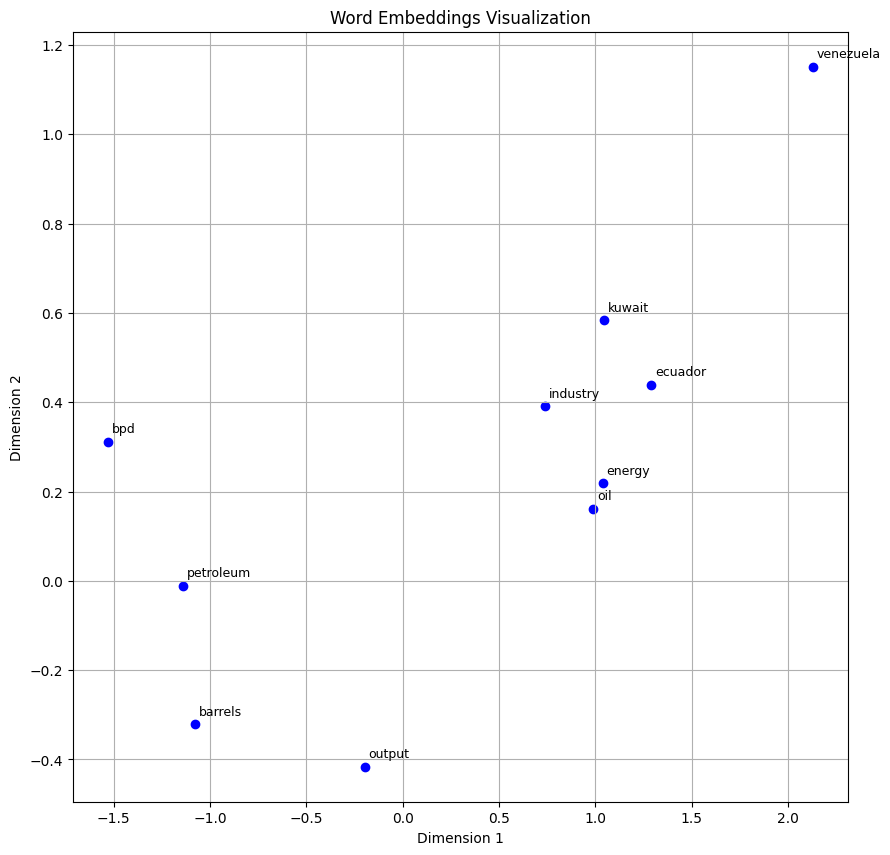

In [23]:
words = ['barrels', 'bpd', 'ecuador', 'energy', 'industry', 'kuwait', 'oil', 'output', 'petroleum', 'venezuela']
plot_embeddings(M_reduced, word2Ind, words)

**Answer (from the seeded plot above).** `oil` and `energy` form the closest visible pair. `industry` is nearby, while `ecuador` and `kuwait` lie in the same general region. However, the oil-related words do not form one compact cluster: `petroleum`, `barrels`, `bpd`, and `output` are separated from `oil` and `energy`. The oil-producing countries also do not all cluster tightly: `venezuela` lies above and to the right of `ecuador` and `kuwait`.

The actual pretrained model here is **GloVe Twitter 25**, despite the section's Word2Vec terminology. These vectors summarize distributional patterns in a large Twitter corpus. Truncated SVD keeps only two directions from 25 dimensions, so proximity in this plot can lose information from the original space and need not match every semantic expectation.

This supplied notebook does **not** contain the earlier co-occurrence-matrix plot mentioned in the question. Therefore, an empirical comparison with that missing figure cannot be made. Conceptually, a raw co-occurrence representation reflects the chosen corpus/window and is often sparse, whereas these pretrained GloVe vectors are dense representations learned from global co-occurrence statistics on a different corpus. The earlier plot that actually appears in this notebook is t-SNE of our trained CBoW vectors; differences from it also involve the corpus, training method, selected words and projection algorithm, so the two layouts are not directly comparable.

### 2.2 Polysemous Words
Find a [polysemous](https://en.wikipedia.org/wiki/Polysemy) word (for example, "leaves" or "scoop") such that the top-10 most similar words (according to cosine similarity) contains related words from both meanings. For example, "leaves" has both "turns" and "ground" in the top 10, and "scoop" has both "buckets" and "pops". You will probably need to try several polysemous words before you find one. Please state the polysemous word you discover and the multiple meanings that occur in the top 10. Why do you think many of the polysemous words you tried didn't work?

Note: You should use the wv_from_bin.most_similar(word) function to get the top 10 similar words. This function ranks all other words in the vocabulary with respect to their cosine similarity to the given word. For further assistance please check the GenSim [documentation](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.FastTextKeyedVectors.most_similar).

In [24]:
polysemy_candidates = ['bank', 'apple', 'mouse', 'leaves', 'scoop', 'rock', 'pitch', 'fan', 'spring', 'light']
polysemy_results = {}
for word in polysemy_candidates:
    polysemy_results[word] = wv_from_bin.most_similar(word, topn=10)
    print(word, ':', polysemy_results[word])

bank : [('unit', 0.8722262978553772), ('service', 0.8568196892738342), ('office', 0.8555631637573242), ('reg', 0.8434539437294006), ('program', 0.8430007696151733), ('company', 0.8412134051322937), ('open', 0.8405929803848267), ('target', 0.8367257714271545), ('bp', 0.8303275108337402), ('private', 0.8243083953857422)]


apple : [('windows', 0.8948712944984436), ('microsoft', 0.8858076333999634), ('google', 0.8823867440223694), ('galaxy', 0.8806391358375549), ('flash', 0.8793812394142151), ('android', 0.8782057762145996), ('nokia', 0.8770236372947693), ('samsung', 0.8697316646575928), ('chrome', 0.8691699504852295), ('ipad', 0.8670315742492676)]
mouse : [('paint', 0.9047009944915771), ('iron', 0.8700125813484192), ('guitar', 0.8695952296257019), ('ninja', 0.8601314425468445), ('cover', 0.8592653870582581), ('metal', 0.8563848733901978), ('mask', 0.8533897399902344), ('shampoo', 0.8532813787460327), ('perfume', 0.8505100607872009), ('patch', 0.8495413661003113)]
leaves : [('turns', 0.9376382231712341), ('stands', 0.9167802929878235), ('takes', 0.9155983328819275), ('breaks', 0.9122216701507568), ('holding', 0.907587468624115), ('sees', 0.906860888004303), ('runs', 0.9057334065437317), ('walks', 0.9046515226364136), ('ground', 0.9041924476623535), ('holds', 0.9032379388809204)]
scoop : [('strip', 0.87048

**Answer.** I selected **light**. Its top ten neighbors include `dark` (0.921761), `sun` (0.908756), and `shadow` (0.900791), which relate to illumination or brightness. They also include `heavy` (0.907935), which relates to the low-weight sense of *light*. Thus words associated with both meanings appear in the same top-ten neighborhood. These neighbors include antonyms because distributional similarity measures shared contexts, rather than synonymy alone.

Several other candidates did not clearly show both senses. For example, `apple` mainly retrieved technology terms such as `windows`, `microsoft`, `google`, and `ipad`, with no clear fruit term in its top ten. `spring` mainly retrieved seasonal or time-related words, rather than a mechanical spring. A static embedding gives each word one vector, merging its senses; a dominant sense in the training corpus can obscure rarer senses. Corpus-specific usage, limited dimensionality and the top-ten cutoff can also hide a sense that is present elsewhere in the vocabulary.

### 2.3: Synonyms & Antonyms

When considering Cosine Similarity, it's often more convenient to think of Cosine Distance, which is simply 1 - Cosine Similarity.

Find three words (w1,w2,w3) where w1 and w2 are synonyms and w1 and w3 are antonyms, but Cosine Distance(w1,w3) < Cosine Distance(w1,w2). For example, w1="happy" is closer to w3="sad" than to w2="cheerful".

Once you have found your example, please give a possible explanation for why this counter-intuitive result may have happened.

You should use the the wv_from_bin.distance(w1, w2) function here in order to compute the cosine distance between two words. Please see the GenSim documentation for further assistance.


In [25]:
# Test several semantically specified synonym/antonym triples, then use a
# counterexample that actually satisfies the required inequality.
triples = [('happy', 'cheerful', 'sad'), ('good', 'excellent', 'bad'),
           ('hot', 'scorching', 'cold'), ('big', 'large', 'small'),
           ('rich', 'wealthy', 'poor'), ('young', 'youthful', 'old')]
distance_results = []
for w1, w2, w3 in triples:
    synonym_distance = float(wv_from_bin.distance(w1, w2))
    antonym_distance = float(wv_from_bin.distance(w1, w3))
    distance_results.append((w1, w2, w3, synonym_distance, antonym_distance))
    print(f'{w1}/{w2}/{w3}: synonym={synonym_distance:.6f}, antonym={antonym_distance:.6f}')
matches = [row for row in distance_results if row[4] < row[3]]
if not matches:
    raise RuntimeError('No tested triple meets the requested inequality')
w1, w2, w3, w1_w2_dist, w1_w3_dist = matches[0]
print(f'Selected: {w1}, {w2}, {w3}; {w1_w3_dist:.6f} < {w1_w2_dist:.6f}')

happy/cheerful/sad: synonym=0.566535, antonym=0.262956
good/excellent/bad: synonym=0.279723, antonym=0.085213
hot/scorching/cold: synonym=0.795029, antonym=0.230165
big/large/small: synonym=0.283211, antonym=0.142084
rich/wealthy/poor: synonym=0.194848, antonym=0.206059
young/youthful/old: synonym=0.589194, antonym=0.129406
Selected: happy, cheerful, sad; 0.262956 < 0.566535


**Answer.** A valid triple is **w1 = happy**, **w2 = cheerful** (synonym), and **w3 = sad** (antonym). The actual cosine distances are:

- distance(happy, cheerful) = **0.566535**
- distance(happy, sad) = **0.262956**

Thus distance(happy, sad) < distance(happy, cheerful), as required. Opposite emotions can occur in similar contexts, such as describing how somebody feels, and may appear in contrasts with each other. Distributional embeddings capture this contextual similarity without explicitly encoding the distinction between synonymy and antonymy. Differences in word frequency and usage in Twitter may also contribute; cosine closeness is not a direct measure of agreement in meaning.

## Task 3: Utilize Word Embeddings

Guess, you've seen such pictures already:  

![Embeddings Relations](https://www.tensorflow.org/images/linear-relationships.png)
*Source: [Tensorflow tutorial on Vector Representations of Words](https://www.tensorflow.org/tutorials/representation/word2vec)*

In the first image, we observe the intricate relationships encoded within the word embeddings space. This encompasses various dimensions like gender differences (male-female) or verb tenses.

**Interactive Exploration**

To delve deeper and interactively explore these relationships, check out these resources:
- [Word Vector Demo](http://bionlp-www.utu.fi/wv_demo/)
- [Word2Viz](https://lamyiowce.github.io/word2viz/)

These tools offer a playful yet insightful experience, allowing you to grasp the nuances and capabilities of word embeddings.

**Our task point**

Our focus will be on utilizing [gensim](https://radimrehurek.com/gensim/), a well-regarded Python library for word embeddings. Gensim makes it effortless to work with and leverage the power of word embeddings in various applications.


### **3.1 Use Pretrained Embeddings**
Base on gensim, we can easily use a well-pretrained embeddings model. There are a number of such models in <font color="blue">gensim</font>, you can call `api.info()` to get the list.

In [26]:
import gensim.downloader as api
# Reuse the identical model already loaded in Task 2.
model = wv_from_bin

**use word embedidngs with gensim**

Yay, we have loaded well-built word embedings models, now let's learn how to use it.

1. To get word's vector, well, call `get_vector`:

In [27]:
model.get_vector('anything')

array([ 0.47841 ,  0.39537 , -0.3216  ,  0.58639 , -0.48316 ,  0.11402 ,
        1.3829  , -0.86081 , -0.81769 , -0.075026, -0.77716 ,  0.58212 ,
       -5.2756  , -0.54024 ,  0.39019 ,  0.3941  ,  0.32682 , -0.7274  ,
        0.49747 , -0.88427 , -0.062516,  0.035716, -0.28677 ,  0.64153 ,
       -0.574   ], dtype=float32)

2. To get most similar words for the given one :

In [28]:
model.most_similar('bread')

[('meat', 0.9616428017616272),
 ('corn', 0.9610626101493835),
 ('cheese', 0.9532765746116638),
 ('noodles', 0.9493104815483093),
 ('soup', 0.9440536499023438),
 ('egg', 0.9418217539787292),
 ('milk', 0.941437304019928),
 ('chicken', 0.9398934841156006),
 ('beans', 0.9390753507614136),
 ('toast', 0.936586856842041)]

3. Analogies with word embeddings

It can do such magic (`woman` + `grandfather` - `man`) :


In [29]:
# Run this cell to answer the analogy -- man : grandfather :: woman : x
model.most_similar(positive=['woman', 'grandfather'], negative=['man'])

[('grandmother', 0.878795325756073),
 ('deceased', 0.8756000399589539),
 ('grandson', 0.8732503652572632),
 ('granddaughter', 0.8626090884208679),
 ('mother-in-law', 0.8423668742179871),
 ('stabs', 0.8338028192520142),
 ('adopted', 0.8286494016647339),
 ('marries', 0.825094997882843),
 ('brother-in-law', 0.8129834532737732),
 ('fiancee', 0.8020613193511963)]

And this too:

In [30]:
model.most_similar([model.get_vector('coder') - model.get_vector('brain') + model.get_vector('money')])

[('gfx', 0.8166243433952332),
 ('realtor', 0.7994468212127686),
 ('promoters', 0.7922900319099426),
 ('promoter', 0.7778065800666809),
 ('recruiter', 0.7722607254981995),
 ('digg', 0.7702906727790833),
 ('sfi', 0.7655168175697327),
 ('chefs', 0.7650213241577148),
 ('smallbusiness', 0.7634385228157043),
 ('realestate', 0.7535584568977356)]

That is, who is like coder, with money and without brains.

**<font color="red">[Task]</font>** : Run an interesting analogy example

**Hint**: Similar to (`woman` + `grandfather` - `man`)

For the example below, `queen` is returned at rank 3 (cosine score about 0.825746), while the top result is `meets`. The expected relationship is present in the neighborhood, but this low-dimensional Twitter model does not solve the analogy perfectly.

In [31]:
# man : king :: woman : ?
analogy_results = model.most_similar(positive=['woman', 'king'], negative=['man'], topn=10)
for word, score in analogy_results:
    print(f'{word:15s} {score:.6f}')

meets           0.884192
prince          0.832163
queen           0.825746
’s              0.817410
crow            0.813499
hunter          0.813104
father          0.811583
soldier         0.811136
mercy           0.808239
hero            0.808226


### **3.2 Finding the Most Similar Sentence**

In this section, we present a method for sentence retrieval based on word embeddings.

The key point is to construct *sentence embeddings*. The simplest method to obtain a sentence embedding is by averaging the embeddings of the words within the sentence.

*You are probably thinking, 'What a dumb idea, why on earth the average of embedding should contain any useful information'. Well, check [this paper](https://arxiv.org/pdf/1805.09843.pdf).*



1. Get Sentence Embedding

**<font color="red">[Task]</font>** : Implement a function to compute sentence embeddings.

**Hint**: Tokenize and lowercase the texts. Calculate the mean embedding for words with known embeddings.

In [32]:
def get_sentence_embedding(model, sentence):
    """Mean of known, lowercased token vectors; zeros if none are known."""
    words = word_tokenize(sentence.lower()) if isinstance(sentence, str) else [w.lower() for w in sentence]
    sum_embedding = np.zeros(model.vector_size, dtype=np.float32)
    words_in_model = 0
    for word in words:
        if word in model:
            sum_embedding += model.get_vector(word)
            words_in_model += 1
    if words_in_model == 0:
        return sum_embedding
    return sum_embedding / words_in_model

Check it:

In [33]:
vector = get_sentence_embedding(model, "I'm very sure. This never happened to me before...")
assert vector.shape == (model.vector_size,)

2. **Building the Index**

With our method ready, we can now embed all sentences in our corpus for retrieval purposes. In this case, we use data from Quora, sampling 1000 entries randomly, and converting them into sentence embeddings.

In [34]:
quora_data = pd.read_csv(DATA_PATH)
corpus = list(quora_data.sample(1000, random_state=SEED).question1.fillna('').unique())
text_vectors = np.array([get_sentence_embedding(model, sentence) for sentence in corpus])
print('Sentence index:', text_vectors.shape)

Sentence index: (997, 25)


In [35]:
corpus[0]

'How do I play Pokémon GO in Korea?'

3. **Search**

Now we are able perform search of the nearest neighbours to the given sentences in our base!


We'll use cosine similarity of two vectors:
$$\text{cosine_similarity}(x, y) = \frac{x^{T} y}{||x||\cdot ||y||}$$

*It's not a [distance](https://www.encyclopediaofmath.org/index.php/Metric) strictly speaking but we still can use it to search for the sentence vectors.*

**<font color="red">[Task]</font>** : IImplement the following function.

**Hint:** Calc the similarity between `query` embedding and `text_vectors` using `cosine_similarity` function. Find `k` vectors with highest scores and return corresponding texts from `texts` list.

In [36]:
from sklearn.metrics.pairwise import cosine_similarity

def find_nearest(model, text_vectors, texts, query, k=10):
    if k < 0:
        raise ValueError('k must be non-negative')
    if len(text_vectors) != len(texts):
        raise ValueError('text_vectors and texts must contain the same number of items')
    if k == 0 or len(texts) == 0:
        return []
    query_vec = get_sentence_embedding(model, query)
    scores = cosine_similarity(query_vec.reshape(1, -1), text_vectors)[0]
    # Stable sorting makes ties deterministic, including all-OOV queries.
    top_indices = np.argsort(-scores, kind='stable')[:min(k, len(texts))]
    return [texts[i] for i in top_indices]

Check it!

In [37]:
find_nearest(model, text_vectors, corpus, "What's your biggest regret in life?", k=10)

['What is the turning point in your life?',
 'What should the purpose of your life?',
 'What is the most painful/humiliating punishment you ever received in your life?',
 'What are the embarrassing moment of your life?',
 'What does it mean when you keep having the same dream over and over of the same dead person?',
 'Is it good to have sex before a marriage?',
 'In the end, what seems to be the most important things in life?',
 'What is the purpose of life?',
 "I have failed the JEE Mains even after taking a drop. My dad has done a lot of investment in this and my relatives seek moments like this to piss me off. I'm very depressed right now. How do I overcome this?",
 'What are the basic things that one should keep in mind before starting a start up?']

### **Bias of Word Embeddings**

It's important to be cognizant of the biases (gender, race, sexual orientation etc.) implicit in our word embeddings. Bias can be dangerous because it can reinforce stereotypes through applications that employ these models.



Here's an example showing word embeddings biases on gender:

In [38]:
print(model.most_similar(positive=['man', 'profession'], negative=['woman']))
print()
print(model.most_similar(positive=['woman', 'profession'], negative=['man']))

[('maths', 0.7983574867248535), ('basis', 0.7973601818084717), ('humør', 0.7948898673057556), ('cert', 0.7902684807777405), ('mulig', 0.7874146699905396), ('spændende', 0.7728654742240906), ('dårligt', 0.7700906991958618), ('latter', 0.7676339745521545), ('noget', 0.7676041722297668), ('vet', 0.7675378918647766)]

[('representation', 0.871566116809845), ('encourages', 0.8626720309257507), ('empowering', 0.8612703084945679), ('intellectual', 0.8564386963844299), ('influences', 0.8559868931770325), ('ethical', 0.8550472259521484), ('affairs', 0.8541139960289001), ('behaviors', 0.8481355905532837), ('advocacy', 0.8439522981643677), ('critic', 0.8406821489334106)]


**<font color="red">[Task]</font>** Identify an example of bias.

**Hint:** Consider providing an example from perspectives such as race or sexual orientation.

In [39]:
# Probe gender associations with occupations. Differences are properties of
# this corpus-trained representation, not claims about people's abilities.
bias_results = []
for occupation in ['nurse', 'engineer', 'doctor', 'programmer', 'homemaker']:
    sim_woman = float(model.similarity(occupation, 'woman'))
    sim_man = float(model.similarity(occupation, 'man'))
    bias_results.append({'occupation': occupation, 'woman_similarity': sim_woman,
                         'man_similarity': sim_man, 'woman_minus_man': sim_woman - sim_man})
bias_table = pd.DataFrame(bias_results)
print(bias_table.to_string(index=False, float_format=lambda x: f'{x:.6f}'))
print('man : computer_programmer :: woman : ?',
      model.most_similar(positive=['woman', 'programmer'], negative=['man'], topn=10))

occupation  woman_similarity  man_similarity  woman_minus_man
     nurse          0.635092        0.462567         0.172525
  engineer          0.477637        0.381555         0.096082
    doctor          0.724820        0.690761         0.034059
programmer          0.356278        0.184690         0.171588
 homemaker          0.200550       -0.096672         0.297222
man : computer_programmer :: woman : ? [('sourcing', 0.8578739762306213), ('marketer', 0.8558772802352905), ('optimization', 0.8489900827407837), ('traveller', 0.8439235091209412), ('strategist', 0.8393991589546204), ('telesales', 0.8304333686828613), ('caregiver', 0.8303733468055725), ('curation', 0.8273847103118896), ('manpower', 0.8204442858695984), ('entrepreneur', 0.8195655941963196)]


**<font color="red">[Task]</font>** Thinking About Bias.

**Hint:** Briefly explain how bias can be introduced into word embeddings and suggest one method to mitigate these biases.

**Answer.** The occupation probe gives an example of gender-associated asymmetry in the actual model: cosine similarity(`homemaker`, `woman`) is **0.200550**, while cosine similarity(`homemaker`, `man`) is **-0.096672**, a difference of **0.297222**. `nurse` also has a larger similarity to `woman` (**0.635092**) than to `man` (**0.462567**). These associations can encode conventional gender roles and can be propagated into downstream retrieval or recommendation systems.

This small probe is evidence of associations in this embedding space, not evidence about people's abilities or a complete fairness evaluation. In this run, `engineer` and `programmer` also have positive woman-minus-man differences, so the results do not justify a blanket claim that every technical occupation is associated more strongly with men. The analogy output is also noisy and should be interpreted cautiously.

Bias can enter embeddings because training texts reflect unequal representation, historical stereotypes, and biased language; preprocessing and the learning objective then compress those patterns into vectors. One mitigation is **counterfactual data augmentation**: balance suitable training sentences by exchanging gendered references while keeping occupations and meaning consistent, then retrain. This can reduce spurious gender-occupation correlations, but needs careful handling of sentences where gender is relevant and evaluation of both association bias and downstream task quality. It does not guarantee removal of all social bias.

## Supplementary Materials
Source from [DeepNLP-Course of DanAnastasyev](https://colab.research.google.com/drive/1o65wrq6RYgWyyMvNP8r9ZknXBniDoXrn#forceEdit=true&offline=true&sandboxMode=true)

## To read
### Blogs
[On word embeddings - Part 1, Sebastian Ruder](http://ruder.io/word-embeddings-1/)  
[On word embeddings - Part 2: Approximating the Softmax, Sebastian Ruder](http://ruder.io/word-embeddings-softmax/index.html)  
[Word2Vec Tutorial - The Skip-Gram Model, Chris McCormick](http://mccormickml.com/2016/04/19/word2vec-tutorial-the-skip-gram-model/)  
[Word2Vec Tutorial Part 2 - Negative Sampling, Chris McCormick](http://mccormickml.com/2017/01/11/word2vec-tutorial-part-2-negative-sampling/)

### Papers
[Word2vec Parameter Learning Explained (2014), Xin Rong](https://arxiv.org/abs/1411.2738)  
[Neural word embedding as implicit matrix factorization (2014), Levy, Omer, and Yoav Goldberg](http://u.cs.biu.ac.il/~nlp/wp-content/uploads/Neural-Word-Embeddings-as-Implicit-Matrix-Factorization-NIPS-2014.pdf)  

### Enhancing Embeddings
[Two/Too Simple Adaptations of Word2Vec for Syntax Problems (2015), Ling, Wang, et al.](https://www.aclweb.org/anthology/N/N15/N15-1142.pdf)  
[Not All Neural Embeddings are Born Equal (2014)](https://arxiv.org/pdf/1410.0718.pdf)  
[Retrofitting Word Vectors to Semantic Lexicons (2014), M. Faruqui, et al.](https://arxiv.org/pdf/1411.4166.pdf)  
[All-but-the-top: Simple and Effective Postprocessing for Word Representations (2017), Mu, et al.](https://arxiv.org/pdf/1702.01417.pdf)  

### Sentence Embeddings
[Skip-Thought Vectors (2015), Kiros, et al.](https://arxiv.org/pdf/1506.06726)  

### Backpropagation
[Backpropagation, Intuitions, cs231n + next parts in the Module 1](http://cs231n.github.io/optimization-2/)   
[Calculus on Computational Graphs: Backpropagation, Christopher Olah](http://colah.github.io/posts/2015-08-Backprop/)

## To watch
[cs224n "Lecture 2 - Word Vector Representations: word2vec"](https://www.youtube.com/watch?v=ERibwqs9p38&index=2&list=PLqdrfNEc5QnuV9RwUAhoJcoQvu4Q46Lja&t=0s)  
[cs224n "Lecture 5 - Backpropagation"](https://www.youtube.com/watch?v=isPiE-DBagM&index=5&list=PLqdrfNEc5QnuV9RwUAhoJcoQvu4Q46Lja&t=0s)   



## Acknowledgement

This assignment was developed with reference to the following course materials:
- [DeepNLP Course by Dan Anastasyev](https://github.com/DanAnastasyev/DeepNLP-Course?tab=readme-ov-file)
- [Exploring Word Vectors from Stanford's CS224N](https://web.stanford.edu/class/cs224n/assignments/a1_preview/exploring_word_vectors.html)
- [Natural Language Processing course from Princeton University](https://nlp.cs.princeton.edu/cos484-sp21/)
- [Yandex Data School NLP Course Week 1 Seminar](https://colab.research.google.com/github/yandexdataschool/nlp_course/blob/2023/week01_embeddings/seminar.ipynb#scrollTo=9m7GZWVk-jrW)
